In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

device_torch = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device_torch}")


Using device: cuda


In [ ]:

df = pd.read_parquet('research\models\impute_result\df_complete_clean.parquet')
df = df.sort_values('timestamp').reset_index(drop=True)
df['sin_COG'] = np.sin(np.radians(df['COG']))
df['cos_COG'] = np.cos(np.radians(df['COG']))
df['jitter_log'] = np.log1p(df['jitter'])
print(f"Dataset: {len(df)} rows, {df.shape[1]} columns")

Dataset: 204942 rows, 53 columns


In [4]:
SEQ_LEN = 20
GAP_THRESHOLD = 60
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 256
EPOCHS_MSE = 50
EPOCHS_GAN = 60
PATIENCE_MSE = 7
PATIENCE_GAN = 15

In [5]:
BASE_INPUTS = [
    'hour', 'day_of_week',
    'device_pc1', 'device_pc2', 'device_pc3', 'device_pc4',
    'direction_uplink',
    'measured_qos_delay',
    'measurement', 'operator'
]

CAUSAL_CHAIN = [
    {
        'name': 'Level_1a_GPS',
        'targets': ['Latitude', 'Longitude'],
        'extra_inputs': [],
        'auto_inputs': ['Latitude', 'Longitude'],
        'use_gan': False,
    },
    {
        'name': 'Level_1b_Mobility',
        'targets': ['speed_kmh', 'sin_COG', 'cos_COG', 'Altitude'],
        'extra_inputs': ['Latitude', 'Longitude'],
        'auto_inputs': ['speed_kmh', 'sin_COG', 'cos_COG', 'Altitude'],
        'use_gan': False,
    },
    {
        'name': 'Level_1c_Environment',
        'targets': ['precipIntensity', 'precipProbability', 'temperature',
                     'humidity', 'windSpeed', 'Traffic Jam Factor',
                     'Traffic Distance'],
        'extra_inputs': ['Latitude', 'Longitude'],
        'auto_inputs': ['precipIntensity', 'precipProbability', 'temperature',
                        'humidity', 'windSpeed', 'Traffic Jam Factor',
                        'Traffic Distance'],
        'use_gan': False,
    },
    {
        'name': 'Level_2a_CellConfig',
        'targets': ['PCell_freq_MHz', 'PCell_Downlink_frequency',
                     'PCell_Band_Indicator',
                     'PCell_Downlink_bandwidth_MHz',
                     'PCell_Uplink_bandwidth_MHz'],
        'extra_inputs': ['Latitude', 'Longitude', 'speed_kmh', 'sin_COG', 'cos_COG',
                         'Altitude', 'precipIntensity', 'precipProbability', 'temperature',
                         'humidity', 'windSpeed', 'Traffic Jam Factor', 'Traffic Distance'],
        'auto_inputs': ['PCell_freq_MHz', 'PCell_Downlink_frequency',
                        'PCell_Band_Indicator',
                        'PCell_Downlink_bandwidth_MHz',
                        'PCell_Uplink_bandwidth_MHz'],
        'use_gan': False,
    },
    {
        'name': 'Level_2b_Signal_QoS',
        'targets': [
            'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
            'PCell_SNR_1', 'PCell_SNR_2',
            'PCell_Downlink_Average_MCS',
            'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
            'PCell_DL_RBs_MCS_Low', 'PCell_DL_RBs_MCS_Mid',
            'PCell_DL_RBs_MCS_High',
            'PCell_Uplink_Num_RBs', 'PCell_Uplink_TB_Size',
            'PCell_Uplink_Tx_Power_(dBm)',
            'datarate', 'jitter_log', 'ping_ms',
            'target_datarate', 'Pos in Ref Round',
        ],
        'extra_inputs': [
            'Latitude', 'Longitude', 'speed_kmh', 'sin_COG', 'cos_COG',
            'Altitude', 'precipIntensity', 'precipProbability', 'temperature',
            'humidity', 'windSpeed', 'Traffic Jam Factor', 'Traffic Distance',
            'PCell_freq_MHz', 'PCell_Downlink_frequency',
            'PCell_Band_Indicator',
            'PCell_Downlink_bandwidth_MHz',
            'PCell_Uplink_bandwidth_MHz',
        ],
        'auto_inputs': [
            'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
            'PCell_SNR_1', 'PCell_SNR_2',
            'PCell_Downlink_Average_MCS',
            'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
            'PCell_DL_RBs_MCS_Low', 'PCell_DL_RBs_MCS_Mid',
            'PCell_DL_RBs_MCS_High',
            'PCell_Uplink_Num_RBs', 'PCell_Uplink_TB_Size',
            'PCell_Uplink_Tx_Power_(dBm)',
            'datarate', 'jitter_log', 'ping_ms',
            'target_datarate', 'Pos in Ref Round',
        ],
        'use_gan': True,
    },
]

SNAP_RULES = {
    'PCell_Downlink_frequency': [125.0, 475.0, 1300.0, 1801.0, 2850.0, 3050.0, 3749.0, 9460.0],
    'PCell_freq_MHz': [700.0, 900.0, 1800.0, 2000.0, 2100.0, 2600.0],
    'PCell_Band_Indicator': [1.0, 3.0, 7.0, 8.0, 28.0],
    'PCell_Downlink_bandwidth_MHz': [5.0, 10.0, 15.0, 20.0],
    'PCell_Uplink_bandwidth_MHz': [5.0, 10.0, 15.0, 20.0],
    'PCell_Downlink_Average_MCS': list(range(0, 30)),
}

In [6]:
def snap_to_nearest(values, valid_set):
    valid_arr = np.array(valid_set)
    result = np.empty_like(values)
    for i, v in enumerate(values):
        result[i] = valid_arr[np.argmin(np.abs(valid_arr - v))]
    return result

ALL_GENERATED_COLS = []
for level in CAUSAL_CHAIN:
    ALL_GENERATED_COLS.extend(level['targets'])

In [7]:

GPS_FEATURES = ['Latitude', 'Longitude']
SIGNAL_FEATURES = ['PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
                    'PCell_SNR_1', 'PCell_SNR_2']
BOUNDED_FEATURES = ['speed_kmh', 'Altitude', 'sin_COG', 'cos_COG',
                     'temperature', 'humidity', 'precipIntensity',
                     'precipProbability', 'windSpeed', 'Traffic Jam Factor']

class GroupScaler:
    def __init__(self, feature_list):
        self.feature_list = feature_list
        self.scalers = {}
        self.groups = {'standard': [], 'robust': [], 'minmax': []}
        for i, feat in enumerate(feature_list):
            if feat in GPS_FEATURES:
                self.groups['standard'].append(i)
            elif feat in SIGNAL_FEATURES:
                self.groups['robust'].append(i)
            elif feat in BOUNDED_FEATURES:
                self.groups['minmax'].append(i)
            else:
                self.groups['standard'].append(i)
        self.scalers['standard'] = StandardScaler()
        self.scalers['robust'] = RobustScaler()
        self.scalers['minmax'] = MinMaxScaler()

    def fit(self, X):
        for name, indices in self.groups.items():
            if len(indices) > 0:
                self.scalers[name].fit(X[:, indices])
        return self

    def transform(self, X):
        X_out = np.zeros_like(X)
        for name, indices in self.groups.items():
            if len(indices) > 0:
                X_out[:, indices] = self.scalers[name].transform(X[:, indices])
        return X_out

    def inverse_transform(self, X):
        X_out = np.zeros_like(X)
        for name, indices in self.groups.items():
            if len(indices) > 0:
                X_out[:, indices] = self.scalers[name].inverse_transform(X[:, indices])
        return X_out



In [8]:

# Standard GRU for MSE levels
class SimpleGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

# Generator for GAN level
class GeneratorGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.gru = nn.GRU(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim * 2)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        mean = out[:, :self.output_dim]
        log_var = out[:, self.output_dim:]
        log_var = torch.clamp(log_var, -6, -1)  # σ range: 0.05 to 0.6
        return mean, log_var

    def sample(self, x):
        mean, log_var = self.forward(x)
        std = torch.exp(0.5 * log_var)
        return mean + std * torch.randn_like(std)

# Discriminator for GAN level
class DiscriminatorLSTM(nn.Module):
    def __init__(self, context_dim, target_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=context_dim + target_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, context_seq, targets):
        targets_exp = targets.unsqueeze(1).expand(-1, context_seq.size(1), -1)
        combined = torch.cat([context_seq, targets_exp], dim=2)
        out, _ = self.lstm(combined)
        return self.classifier(out[:, -1, :])

In [9]:

print("\nSegmenting data by device")
device_cols_list = ['device_pc1', 'device_pc2', 'device_pc3', 'device_pc4']
all_segments = []

for d_col in device_cols_list:
    sub = df[df[d_col] == 1].sort_values('timestamp').reset_index(drop=True)
    gaps = sub['timestamp'].diff().dt.total_seconds()
    break_indices = gaps[gaps > GAP_THRESHOLD].index.tolist()
    starts = [0] + break_indices
    ends = break_indices + [len(sub)]
    for s, e in zip(starts, ends):
        seg = sub.iloc[s:e].reset_index(drop=True)
        if len(seg) >= SEQ_LEN + 5:
            all_segments.append(seg)

print(f"Total segments: {len(all_segments)}")
print(f"Total rows: {sum(len(s) for s in all_segments)}")


Segmenting data by device
Total segments: 64
Total rows: 204942


In [10]:

all_timestamps = df['timestamp'].sort_values()
n = len(all_timestamps)
t_train_end = pd.Timestamp(all_timestamps.iloc[int(n * 0.70)])
t_val_end = pd.Timestamp(all_timestamps.iloc[int(n * 0.85)])
print(f"Train cutoff: {t_train_end}")
print(f"Val cutoff:   {t_val_end}")

def get_split(ts):
    ts = pd.Timestamp(ts, tz='Europe/Berlin')
    if ts <= t_train_end:
        return 'train'
    elif ts <= t_val_end:
        return 'val'
    else:
        return 'test'

Train cutoff: 2021-06-23 15:51:37+02:00
Val cutoff:   2021-06-24 10:19:02+02:00


In [12]:

def create_sequences_autoreg(segments, context_cols, auto_cols, target_cols, split='train'):
    X_list, y_list, ts_list = [], [], []
    for seg_df in segments:
        seg_timestamps = seg_df['timestamp'].values
        seg_context = seg_df[context_cols].values
        seg_auto = seg_df[auto_cols].values
        seg_targets = seg_df[target_cols].values
        for i in range(SEQ_LEN, len(seg_df)):
            target_ts = seg_timestamps[i]
            if get_split(pd.Timestamp(target_ts)) != split:
                continue
            ctx = seg_context[i - SEQ_LEN:i]
            auto = seg_auto[i - SEQ_LEN:i].copy()
            auto[-1, :] = 0.0
            x = np.concatenate([ctx, auto], axis=1)
            y = seg_targets[i]
            X_list.append(x)
            y_list.append(y)
            ts_list.append(target_ts)
    if len(X_list) == 0:
        return None, None, None
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y, ts_list

In [20]:

def train_level_mse(level_name, context_cols, auto_cols, target_cols,
                    segments, scalers_dict):

    print(f"{'_'*60}")
    print(f"  {level_name} (MSE)")
    print(f"  Targets ({len(target_cols)}): {target_cols}")
    print(f"{'_'*60}")

    t0 = time.time()

    X_train, y_train, _ = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'train')
    X_val, y_val, _ = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'val')
    X_test, y_test, ts_test = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'test')

    print(f"  Sequences — Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    n_input_feat = X_train.shape[2]
    all_input_cols = context_cols + auto_cols
    input_scaler = GroupScaler(all_input_cols)
    input_scaler.fit(X_train.reshape(-1, n_input_feat))
    X_train = input_scaler.transform(X_train.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    X_val = input_scaler.transform(X_val.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    X_test = input_scaler.transform(X_test.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    scalers_dict[f"{level_name}_input"] = input_scaler

    target_scaler = GroupScaler(target_cols)
    target_scaler.fit(y_train)
    y_train_scaled = target_scaler.transform(y_train)
    y_val_scaled = target_scaler.transform(y_val)
    scalers_dict[f"{level_name}_target"] = target_scaler

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_scaled))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val_scaled))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SimpleGRU(
        input_dim=n_input_feat, hidden_dim=HIDDEN_SIZE,
        output_dim=len(target_cols), num_layers=NUM_LAYERS, dropout=DROPOUT
    ).to(device_torch)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(EPOCHS_MSE):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device_torch), y_batch.to(device_torch)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device_torch), y_batch.to(device_torch)
                loss = criterion(model(X_batch), y_batch)
                val_loss += loss.item() * len(X_batch)
        val_loss /= len(val_ds)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0

        else:
            patience_counter += 1


        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f} | Pat: {patience_counter}")

        if patience_counter >= PATIENCE_MSE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.eval()

    # Evaluate
    X_test_tensor = torch.FloatTensor(X_test).to(device_torch)
    with torch.no_grad():
        pred_test_scaled = model(X_test_tensor).cpu().numpy()
    pred_test = target_scaler.inverse_transform(pred_test_scaled)

    elapsed = time.time() - t0
    level_results = {}
    print(f"\n  {'Feature':40s} | {'RMSE':>10s} | {'MAE':>10s}")
    print(f"  {'─'*65}")
    for i, target in enumerate(target_cols):
        pred_col = pred_test[:, i].copy()
        if target in SNAP_RULES:
            pred_col = snap_to_nearest(pred_col, SNAP_RULES[target])
        rmse = np.sqrt(mean_squared_error(y_test[:, i], pred_col))
        mae = mean_absolute_error(y_test[:, i], pred_col)
        level_results[target] = {
            'level': level_name, 'rmse_test_tf': rmse,
            'mae_test_tf': mae, 'learned_std': 0.0,
        }
        print(f"  {target:40s} | {rmse:10.4f} | {mae:10.4f}")

    print(f"  Training time: {elapsed:.1f}s")
    return model, level_results


In [21]:
GAN_HIDDEN = 256
GAN_BATCH = 64
D_LR = 5e-5

In [25]:

def train_level_gan(level_name, context_cols, auto_cols, target_cols,
                    segments, scalers_dict):
    print(f"{'_'*60}")
    print(f"  {level_name} (MSE+GAN)")
    print(f"  Targets ({len(target_cols)}): {target_cols}")
    print(f"{'_'*60}")

    t0 = time.time()

    X_train, y_train, _ = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'train')
    X_val, y_val, _ = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'val')
    X_test, y_test, ts_test = create_sequences_autoreg(
        segments, context_cols, auto_cols, target_cols, 'test')

    print(f"  Sequences — Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    n_input_feat = X_train.shape[2]
    all_input_cols = context_cols + auto_cols
    n_auto = len(auto_cols)

    input_scaler = GroupScaler(all_input_cols)
    input_scaler.fit(X_train.reshape(-1, n_input_feat))
    X_train = input_scaler.transform(X_train.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    X_val = input_scaler.transform(X_val.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    X_test = input_scaler.transform(X_test.reshape(-1, n_input_feat)).reshape(-1, SEQ_LEN, n_input_feat)
    scalers_dict[f"{level_name}_input"] = input_scaler

    target_scaler = GroupScaler(target_cols)
    target_scaler.fit(y_train)
    y_train_scaled = target_scaler.transform(y_train)
    y_val_scaled = target_scaler.transform(y_val)
    scalers_dict[f"{level_name}_target"] = target_scaler

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_scaled))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val_scaled))
    train_loader = DataLoader(train_ds, batch_size=GAN_BATCH, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=GAN_BATCH, shuffle=False)

    n_targets = len(target_cols)


    # 3. Bigger generator
    generator = SimpleGRU(
        input_dim=n_input_feat, hidden_dim=256,    # same
        output_dim=n_targets, num_layers=3,         # was 2 — deeper
        dropout=0.3                                # was 0.2 — less dropout for bigger model
    ).to(device_torch)

    # 4. Stronger discriminator
    discriminator = DiscriminatorLSTM(
        context_dim=n_input_feat, target_dim=n_targets, hidden_dim=128  # was 64
    ).to(device_torch)


    opt_G = torch.optim.AdamW(generator.parameters(), lr=1e-3, weight_decay=1e-3)
    opt_D = torch.optim.AdamW(discriminator.parameters(), lr=D_LR, weight_decay=1e-4)
    sched_G = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_G, patience=5, factor=0.5)

    bce = nn.BCEWithLogitsLoss()
    mse_criterion = nn.MSELoss()

    PHASE1_END = 20
    TOTAL_EPOCHS = 60
    LAMBDA_ADV = 0.1

    # Initialize history
    history = {
        'mse': [], 'adv': [], 'd_loss': [], 'val_mse': [],
        'phase2_start': PHASE1_END + 1
    }

    print(f"  Generator params: {sum(p.numel() for p in generator.parameters()):,}")
    print(f"  Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")

    best_val_loss = float('inf')
    best_state_G = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(TOTAL_EPOCHS):

        use_adv = epoch >= PHASE1_END
        phase = 2 if use_adv else 1

        # Reset patience and best when entering Phase 2
        if epoch == PHASE1_END:
            patience_counter = 0
            best_val_loss = float('inf')
            best_state_G = {k: v.clone() for k, v in generator.state_dict().items()}
            best_epoch = epoch
            for param_group in opt_G.param_groups:
                param_group['lr'] = 5e-4

        generator.train()
        if use_adv:
            discriminator.train()

        epoch_mse = 0.0
        epoch_adv = 0.0
        epoch_d = 0.0
        n_batches = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device_torch)
            y_batch = y_batch.to(device_torch)
            bs = X_batch.size(0)

            # Training noise on autoregressive inputs
            X_noisy = X_batch.clone()
            X_noisy[:, :-1, -n_auto:] += 0.1 * torch.randn(
                bs, SEQ_LEN - 1, n_auto, device=device_torch)

            # Train Discriminator
            if use_adv:
                for d_step in range(2):  
                    with torch.no_grad():
                        fake_targets = generator(X_noisy)

                    d_real = discriminator(X_batch, y_batch)
                    d_fake = discriminator(X_batch, fake_targets)
                    d_loss = bce(d_real, torch.ones(bs, 1, device=device_torch) * 0.9) + \
                             bce(d_fake, torch.zeros(bs, 1, device=device_torch) + 0.1)

                    opt_D.zero_grad()
                    d_loss.backward()
                    torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
                    opt_D.step()

                epoch_d += d_loss.item()

            # Train Generator 
            fake_targets = generator(X_noisy)
            mse_loss = mse_criterion(fake_targets, y_batch)

            if use_adv:
                d_fake = discriminator(X_batch, fake_targets)
                adv_loss = bce(d_fake, torch.ones(bs, 1, device=device_torch))
                g_loss = mse_loss + LAMBDA_ADV * adv_loss
                epoch_adv += adv_loss.item()
            else:
                g_loss = mse_loss

            opt_G.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            opt_G.step()

            epoch_mse += mse_loss.item()
            n_batches += 1

        # Validation (MSE only)
        generator.eval()
        val_mse = 0.0
        val_total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device_torch)
                y_batch = y_batch.to(device_torch)
                pred = generator(X_batch)
                mse = mse_criterion(pred, y_batch)
                val_mse += mse.item() * X_batch.size(0)
                val_total += X_batch.size(0)

        val_loss = val_mse / val_total
        sched_G.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_G = {k: v.clone() for k, v in generator.state_dict().items()}
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0 or patience_counter == 0:
            print(
                f"  Epoch {epoch+1:3d}  | "
                f"MSE: {epoch_mse/n_batches:.6f} | "
                f"Adv: {epoch_adv/n_batches:.4f} | "
                f"D: {epoch_d/n_batches:.4f} | "
                f"Val_MSE: {val_loss:.6f} | "
                f"Pat: {patience_counter}"
            )

        history['mse'].append(epoch_mse / n_batches)
        history['adv'].append(epoch_adv / n_batches)
        history['d_loss'].append(epoch_d / n_batches)
        history['val_mse'].append(val_loss)

        # No early stopping in Phase 1. Early stop in Phase 2 with patience 15.
        if epoch >= PHASE1_END and patience_counter >= PATIENCE_GAN:
            print(f"  Early stop at epoch {epoch+1}")
            break

   

    print(f"\n  Best epoch: {best_epoch} | Best val MSE: {best_val_loss:.6f}")
    generator.load_state_dict(best_state_G)
    generator.eval()

    

    # Evaluate
    X_test_tensor = torch.FloatTensor(X_test).to(device_torch)
    with torch.no_grad():
        pred_test_scaled = generator(X_test_tensor).cpu().numpy()
    pred_test = target_scaler.inverse_transform(pred_test_scaled)


    elapsed = time.time() - t0
    level_results = {}
    print(f"\n  {'Feature':40s} | {'RMSE':>10s} | {'MAE':>10s}")
    print(f"  {'─'*65}")
    for i, target in enumerate(target_cols):
        pred_col = pred_test[:, i].copy()
        if target in SNAP_RULES:
            pred_col = snap_to_nearest(pred_col, SNAP_RULES[target])
        rmse = np.sqrt(mean_squared_error(y_test[:, i], pred_col))
        mae = mean_absolute_error(y_test[:, i], pred_col)
        level_results[target] = {
            'level': level_name, 'rmse_test_tf': rmse,
            'mae_test_tf': mae, 'learned_std': 0.0,
        }
        print(f"  {target:40s} | {rmse:10.4f} | {mae:10.4f}")

    print(f"  Training time: {elapsed:.1f}s")
    return generator, discriminator, level_results, history, y_test, pred_test, target_cols

In [26]:

# TRAIN ALL LEVELS
print("TRAINING GRU GAN ")

all_models = {}
all_discriminators = {}
all_results = {}
all_scalers = {}
total_start = time.time()

for level in CAUSAL_CHAIN:
    level_name = level['name']
    targets = level['targets']
    extra_inputs = level['extra_inputs']
    auto_inputs = level['auto_inputs']
    context_cols = BASE_INPUTS + extra_inputs

    if level.get('use_gan', False):
        generator, discriminator, level_results, history, y_test, pred_test, target_cols = train_level_gan(
            level_name, context_cols, auto_inputs, targets,
            all_segments, all_scalers
        )
        all_models[level_name] = generator
        all_discriminators[level_name] = discriminator
    else:
        model, level_results = train_level_mse(
            level_name, context_cols, auto_inputs, targets,
            all_segments, all_scalers
        )
        all_models[level_name] = model

    all_results.update(level_results)

total_time = time.time() - total_start

print(f"TOTAL TRAINING TIME: {total_time:.1f}s ({total_time/60:.1f} min)")

TRAINING GRU GAN 
____________________________________________________________
  Level_1a_GPS (MSE)
  Targets (2): ['Latitude', 'Longitude']
____________________________________________________________
  Sequences — Train: 157599, Val: 26910, Test: 19153
  Parameters: 161,986
  Epoch   1 | Train: 0.767563 | Val: 2.326052 | LR: 0.001000 | Pat: 0
  Epoch   5 | Train: 0.260587 | Val: 3.598189 | LR: 0.000500 | Pat: 4
  Early stop at epoch 8

  Feature                                  |       RMSE |        MAE
  ─────────────────────────────────────────────────────────────────
  Latitude                                 |     0.0126 |     0.0099
  Longitude                                |     0.0611 |     0.0547
  Training time: 147.5s
____________________________________________________________
  Level_1b_Mobility (MSE)
  Targets (4): ['speed_kmh', 'sin_COG', 'cos_COG', 'Altitude']
____________________________________________________________
  Sequences — Train: 157599, Val: 26910, Test: 1

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output


In [29]:
import matplotlib.pyplot as plt

def plot_training_curves(history, level_name):
    """Plot Generator Adversarial Loss and Discriminator Loss from epoch 20 onwards."""
    
    stop_epoch = len(history['mse'])
    
    
    start_idx = 20
    epochs = list(range(start_idx + 1, stop_epoch + 1))
    adv  = history['adv'][start_idx:]
    disc = history['d_loss'][start_idx:]
    ideal_d = np.log(4)  # ≈ 1.386

    def style(ax, ylabel, title):
        ax.set_facecolor("#FAFAFA")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#DDDDDD")
        ax.spines["bottom"].set_color("#DDDDDD")
        ax.tick_params(labelsize=9)
        ax.yaxis.grid(True, linestyle=":", alpha=0.5, color="#CCCCCC", zorder=0)
        ax.set_axisbelow(True)
        ax.set_xlabel("Epoch", fontsize=14, labelpad=6)
        ax.set_ylabel(ylabel, fontsize=14, labelpad=6)
        ax.set_title(title, fontsize=16, fontweight="bold",
                     color="#000000", pad=12, loc="left")
        ax.set_xlim(20, stop_epoch + 1)

    # Generator Adversarial Loss
    fig1, ax1 = plt.subplots(figsize=(8, 4.5), facecolor="white")
    style(ax1, "Adversarial loss", "Generator Adversarial Loss")
    ax1.plot(epochs, adv,
             color="#ED7D31", linewidth=2.2,
             marker="o", markersize=5,
             markerfacecolor="white", markeredgewidth=1.5,
             zorder=4, label="Generator adversarial loss")
    ax1.set_ylim(0, 2.6)
    ax1.legend(fontsize=8.5, framealpha=0.9, edgecolor="#DDDDDD", loc="upper left")
    plt.tight_layout()
    plt.savefig("GAN_loss.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: GAN_loss.png")

 
    # Discriminator Loss
    fig2, ax2 = plt.subplots(figsize=(8, 4.5), facecolor="white")
    style(ax2, "Discriminator loss", "Discriminator Loss")
    ax2.plot(epochs, disc,
             color="#3994E9", linewidth=2.2,
             marker="s", markersize=5,
             markerfacecolor="white", markeredgewidth=1.5,
             zorder=4, label="Discriminator loss")
    ax2.set_ylim(0.5, 1.55)
    ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor="#DDDDDD", loc="upper right")
    plt.tight_layout()
    plt.savefig("GAN_disc_loss.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: GAN_disc_loss.png")

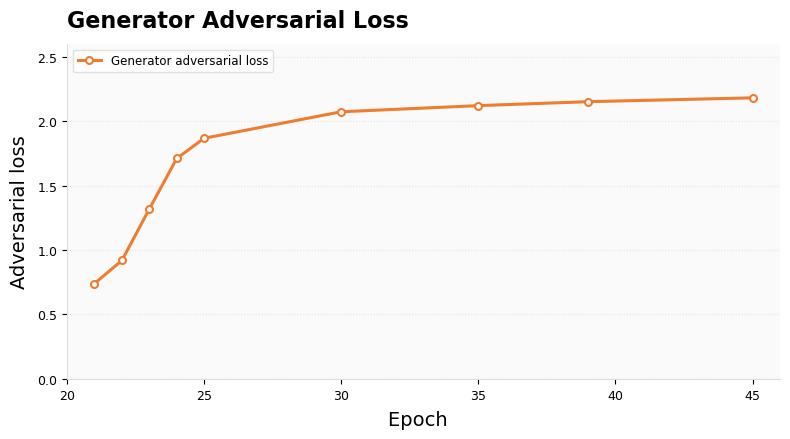

Saved: figure4_3a_gen_adv_loss.png


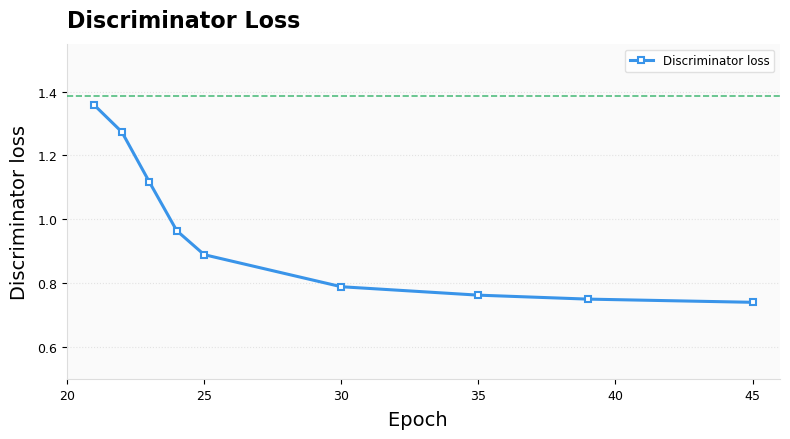

Saved: GAN_disc_loss.png


In [ ]:
# Training Curves
plot_training_curves(history, "Level_2b_Signal_QoS")

In [31]:

# REAL vs GENERATED COMPARISON

def plot_real_vs_generated(y_test, pred_test, target_cols, level_name, n_show=8):
    """Compare distributions and scatter plots for selected features."""
    show_cols = target_cols[:n_show]
    n_cols = 4
    n_rows = (len(show_cols) + n_cols - 1) // n_cols

    # Distribution comparison
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    fig.suptitle(f'{level_name} — Real vs Generated Distributions', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(show_cols):
        idx = target_cols.index(col)
        ax = axes[i]
        ax.hist(y_test[:, idx], bins=60, alpha=0.5, color='steelblue',
                label='Real', density=True)
        ax.hist(pred_test[:, idx], bins=60, alpha=0.5, color='coral',
                label='Generated', density=True)
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

        rmse = np.sqrt(np.mean((y_test[:, idx] - pred_test[:, idx]) ** 2))
        ax.text(0.02, 0.95, f'RMSE={rmse:.3f}', transform=ax.transAxes,
                fontsize=8, va='top', fontweight='bold')

    for i in range(len(show_cols), len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Scatter: Real vs Generated (should be on diagonal if perfect)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    fig.suptitle(f'{level_name} — Real vs Generated Scatter', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(show_cols):
        idx = target_cols.index(col)
        ax = axes[i]

        # Subsample for clarity
        n_plot = min(2000, len(y_test))
        indices = np.random.choice(len(y_test), n_plot, replace=False)

        ax.scatter(y_test[indices, idx], pred_test[indices, idx],
                   alpha=0.1, s=5, color='steelblue')

        # Perfect prediction line
        vmin = min(y_test[:, idx].min(), pred_test[:, idx].min())
        vmax = max(y_test[:, idx].max(), pred_test[:, idx].max())
        ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1, alpha=0.7)

        ax.set_xlabel('Real', fontsize=8)
        ax.set_ylabel('Generated', fontsize=8)
        ax.set_title(col, fontsize=10, fontweight='bold')

        # R² score
        ss_res = np.sum((y_test[:, idx] - pred_test[:, idx]) ** 2)
        ss_tot = np.sum((y_test[:, idx] - y_test[:, idx].mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        ax.text(0.02, 0.95, f'R²={r2:.3f}', transform=ax.transAxes,
                fontsize=8, va='top', fontweight='bold')

    for i in range(len(show_cols), len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()

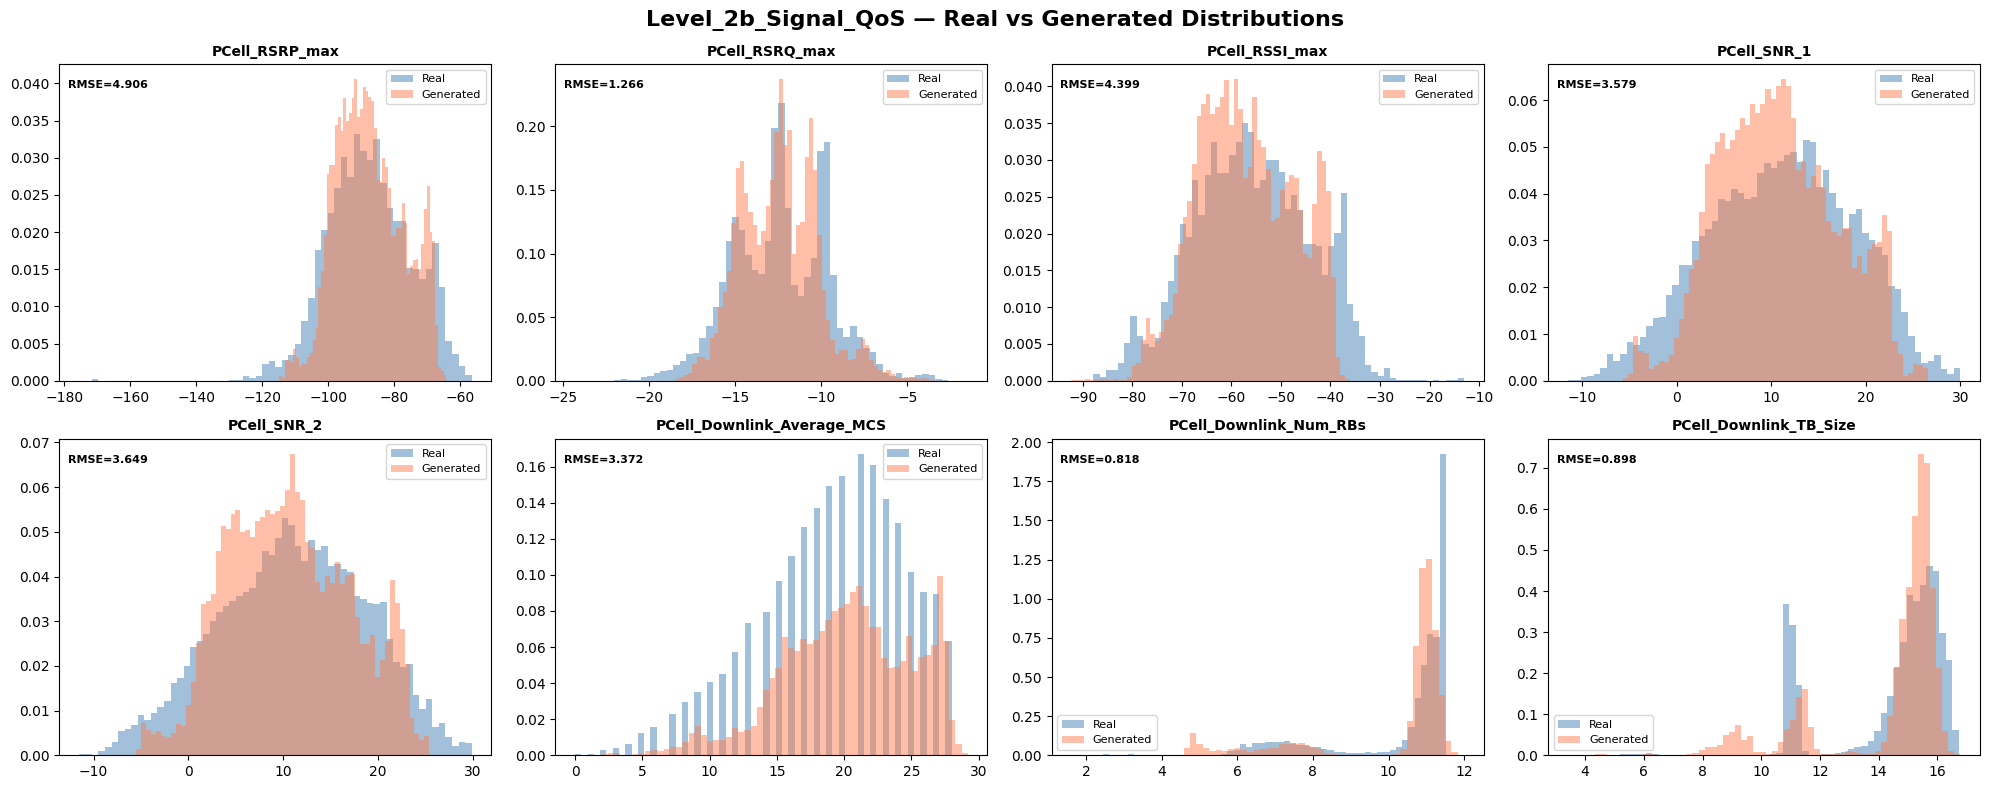

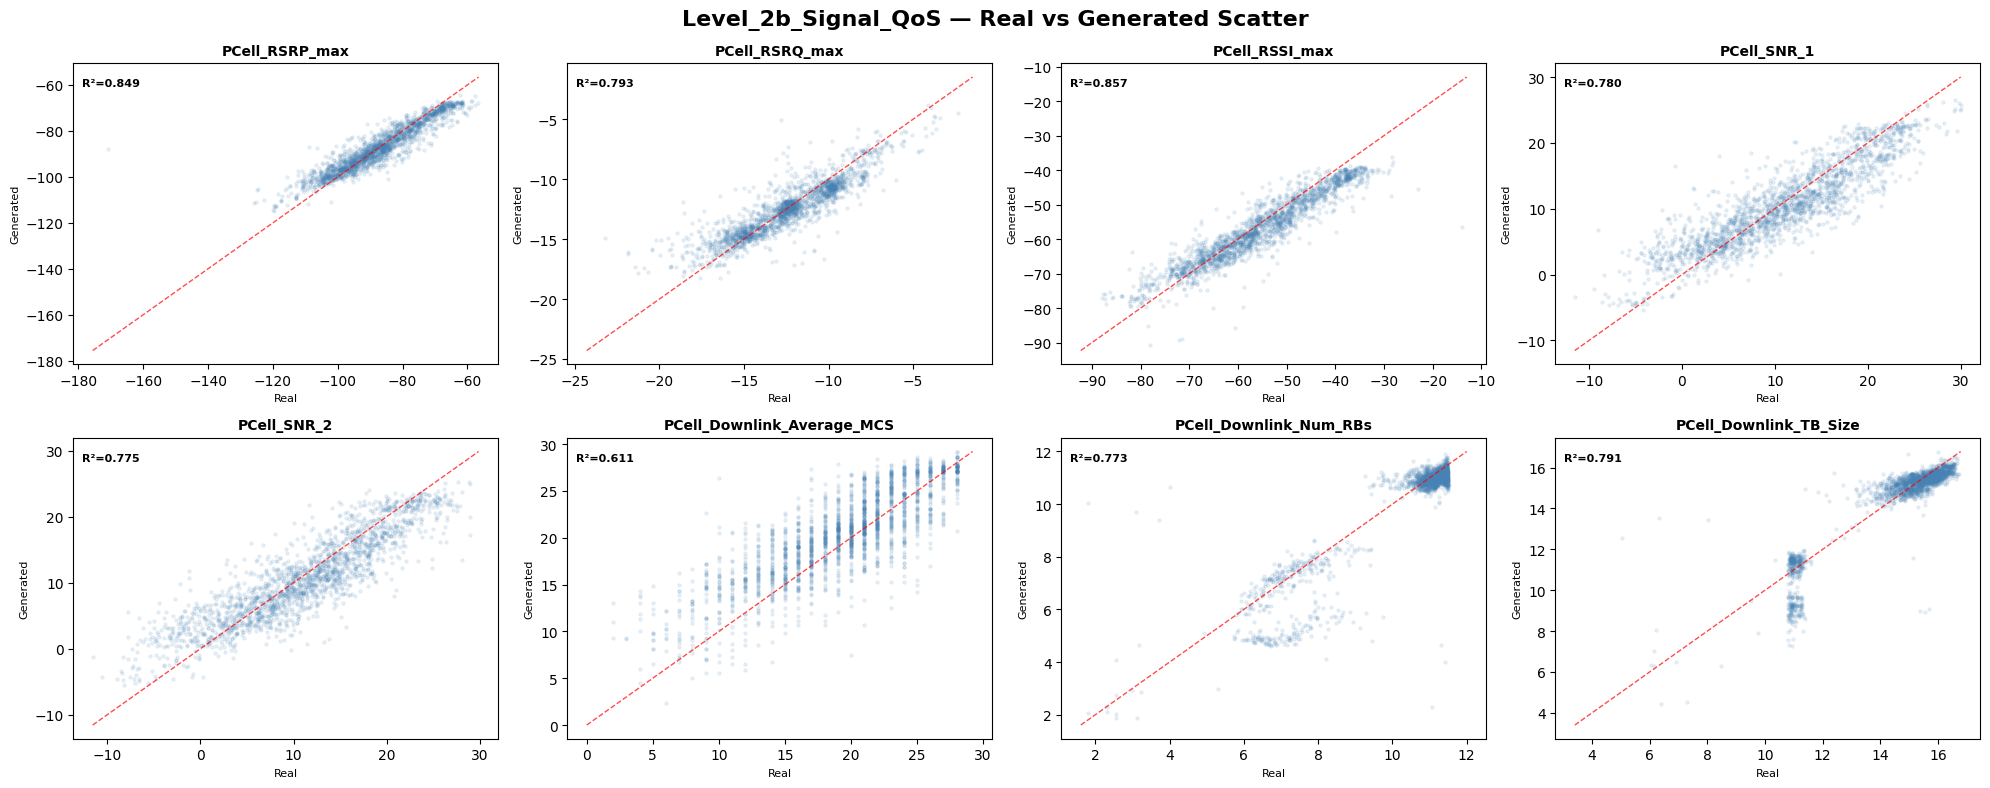

In [32]:
# Real vs Generated Distributions & Scatter
plot_real_vs_generated(y_test, pred_test, target_cols, "Level_2b_Signal_QoS")

In [35]:


def plot_cross_correlations(y_test, pred_test, target_cols, level_name):
    """Compare cross-correlation matrices between real and generated."""
    key_features = []
    for f in ['PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
              'PCell_SNR_1', 'PCell_SNR_2', 'datarate', 'ping_ms',
              'speed_kmh', 'PCell_Downlink_Average_MCS']:
        if f in target_cols:
            key_features.append(f)

    if len(key_features) < 3:
        return

    indices = [target_cols.index(f) for f in key_features]
    short_names = [f.replace('PCell_', '').replace('Downlink_', 'DL_') for f in key_features]

    real_corr = np.corrcoef(y_test[:, indices].T)
    gen_corr = np.corrcoef(pred_test[:, indices].T)
    diff_corr = np.abs(real_corr - gen_corr)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'{level_name} — Cross-Correlation Comparison', fontsize=16, fontweight='bold')

    for ax, data, title, cmap in [
        (axes[0], real_corr, 'Real', 'RdBu_r'),
        (axes[1], gen_corr, 'Generated', 'RdBu_r'),
        (axes[2], diff_corr, '|Difference|', 'Reds'),
    ]:
        im = ax.imshow(data, cmap=cmap, vmin=-1 if cmap == 'RdBu_r' else 0,
                       vmax=1, aspect='auto')
        ax.set_xticks(range(len(short_names)))
        ax.set_yticks(range(len(short_names)))
        ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_title(title, fontsize=12, fontweight='bold')

        # Add correlation values
        for i in range(len(short_names)):
            for j in range(len(short_names)):
                color = 'white' if abs(data[i, j]) > 0.5 else 'black'
                ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                        fontsize=6, color=color)

        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.show()

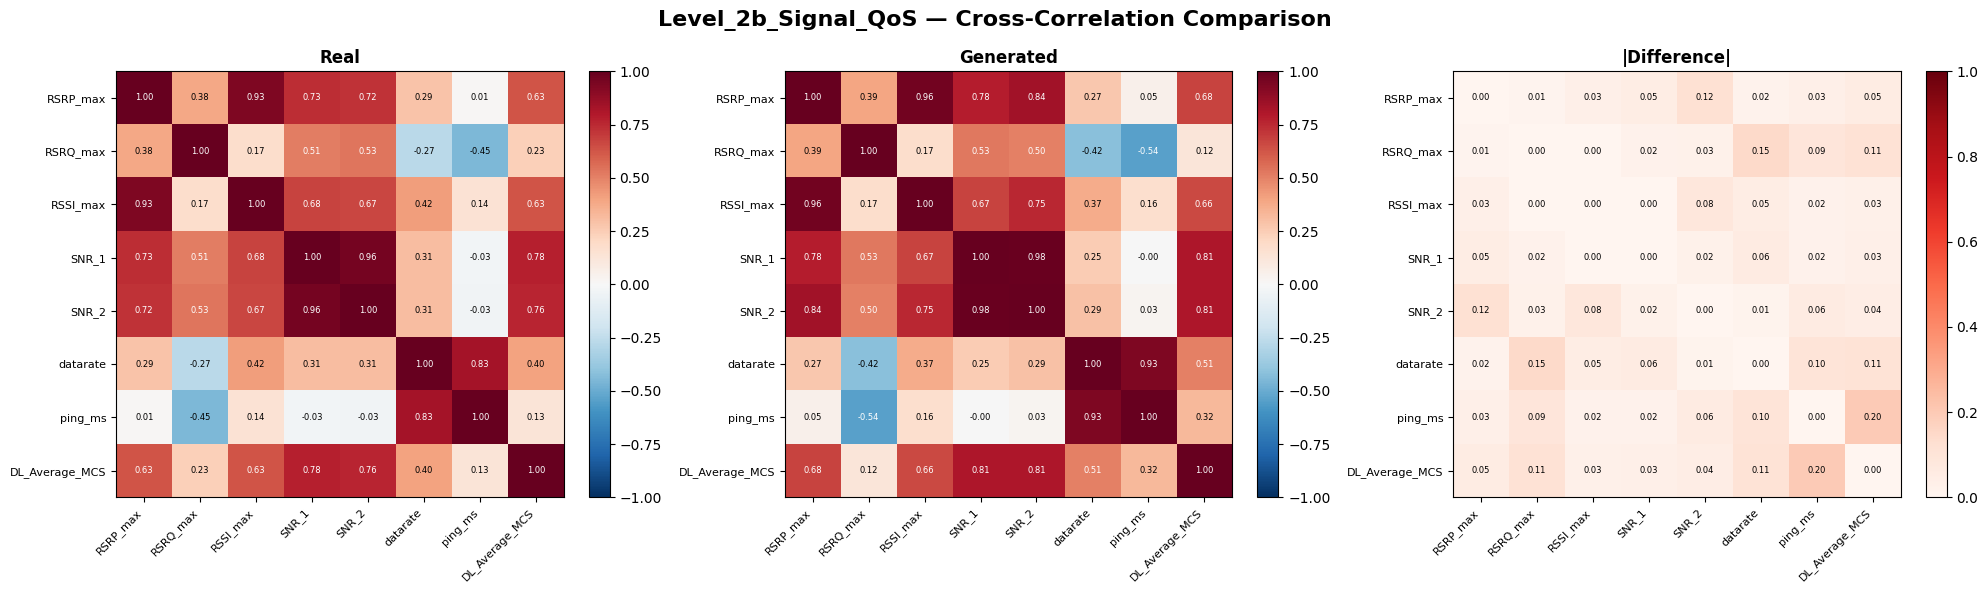

In [36]:
# Cross-Correlation Heatmap
plot_cross_correlations(y_test, pred_test, target_cols, "Level_2b_Signal_QoS")

In [37]:

print(f"HYBRID CHAIN RESULTS")
print(f"{'_'*85}")

# In the final results print, change:
print(f"{'Feature':40s} | {'Level':25s} | {'RMSE':>10s} | {'MAE':>10s}")
print(f"{'_'*85}")

for target, res in all_results.items():
    print(f"{target:40s} | {res['level']:25s} | {res['rmse_test_tf']:10.4f} | "
          f"{res['mae_test_tf']:10.4f}")

HYBRID CHAIN RESULTS
_____________________________________________________________________________________
Feature                                  | Level                     |       RMSE |        MAE
_____________________________________________________________________________________
Latitude                                 | Level_1a_GPS              |     0.0126 |     0.0099
Longitude                                | Level_1a_GPS              |     0.0611 |     0.0547
speed_kmh                                | Level_1b_Mobility         |     0.5129 |     0.3457
sin_COG                                  | Level_1b_Mobility         |     0.1149 |     0.0861
cos_COG                                  | Level_1b_Mobility         |     0.0780 |     0.0437
Altitude                                 | Level_1b_Mobility         |     1.3914 |     1.1017
precipIntensity                          | Level_1c_Environment      |     0.1056 |     0.0864
precipProbability                        | Leve

In [ ]:

SAVE_DIR = 'outputs_gan'

torch.save(
    {name: m.state_dict() for name, m in all_models.items()},
    f'{SAVE_DIR}/gru_gan_models.pt'
)
torch.save(
    {name: d.state_dict() for name, d in all_discriminators.items()},
    f'{SAVE_DIR}/gru_gan_discriminators.pt'
)
pickle.dump(all_scalers, open(f'{SAVE_DIR}/gru_gan_scalers.pkl', 'wb'))
pickle.dump(all_results, open(f'{SAVE_DIR}/gru_gan_results.pkl', 'wb'))

chain_config = {
    'CAUSAL_CHAIN': CAUSAL_CHAIN,
    'BASE_INPUTS': BASE_INPUTS,
    'SNAP_RULES': SNAP_RULES,
    'SEQ_LEN': SEQ_LEN,
    'HIDDEN_SIZE': HIDDEN_SIZE,
    'NUM_LAYERS': NUM_LAYERS,
    'DROPOUT': DROPOUT,
    'ALL_GENERATED_COLS': ALL_GENERATED_COLS,
}
pickle.dump(chain_config, open(f'{SAVE_DIR}/gru_gan_config.pkl', 'wb'))

print(f"\nSaved to {SAVE_DIR}/")
print("  gru_gan_models.pt")
print("  gru_gan_discriminators.pt")
print("  gru_gan_scalers.pkl")
print("  gru_gan_results.pkl")
print("  gru_gan_config.pkl")
